#### B.6. Implement  a  hierarchical  clustering  algorithm  and  display  the  clustering  results  using  a Dendrogram or a Venn Diagram. 

# Hierarchical Clustering

Hierarchical clustering involves creating clusters that have a predetermined ordering from top to bottom. For example, all files and folders on the hard disk are organized in a hierarchy. There are two types of hierarchical clustering, Divisive and Agglomerative.

**Divisive method**

In this method we assign all of the observations to a single cluster and then partition the cluster to two least similar clusters. Finally, we proceed recursively on each cluster until there is one cluster for each observation.

**Agglomerative method**
		
In this method we assign each observation to its own cluster. Then, compute the similarity (e.g., distance) between each of the clusters and join the two most similar clusters. Finally, repeat steps 2 and 3 until there is only a single cluster left.

## Linkage or distance matrix

Before any clustering is performed, it is required to determine the proximity matrix containing the distance between each point using a distance function. Then, the matrix is updated to display the distance between each cluster. The following three methods differ in how the distance between each cluster is measured.

**Single Linkage** 		
In single linkage hierarchical clustering, the distance between two clusters is defined as the shortest distance between two points in each cluster. For example, the distance between clusters “r” and “s” to the left is equal to the length of the arrow between their two closest points.
<img src=http://www.saedsayad.com/images/Clustering_single.png>

**Complete Linkage**		
In complete linkage hierarchical clustering, the distance between two clusters is defined as the longest distance between two points in each cluster. For example, the distance between clusters “r” and “s” to the left is equal to the length of the arrow between their two furthest points.
<img src=http://www.saedsayad.com/images/Clustering_complete.png>

**Average Linkage**	
In average linkage hierarchical clustering, the distance between two clusters is defined as the average distance between each point in one cluster to every point in the other cluster. For example, the distance between clusters “r” and “s” to the left is equal to the average length each arrow between connecting the points of one cluster to the other.
<img src=http://www.saedsayad.com/images/Clustering_average.png>

## Dendograms

[Dendograms](https://en.wikipedia.org/wiki/Dendrogram) are tree diagrams frequently used to illustrate the arrangement of the clusters produced by hierarchical clustering. The clades are arranged according to how similar (or dissimilar) they are. Clades that are close to the same height are similar to each other; clades with different heights are dissimilar — the greater the difference in height, the more dissimilarity. 

An example involving the famous Iris data set is shown below.

<img src=https://upload.wikimedia.org/wikipedia/commons/1/12/Iris_dendrogram.png height='400px' width = '400px'>

[[4, 21], [5, 19], [10, 24], [4, 17], [3, 16], [11, 25], [14, 24], [6, 22], [10, 21], [12, 21]]


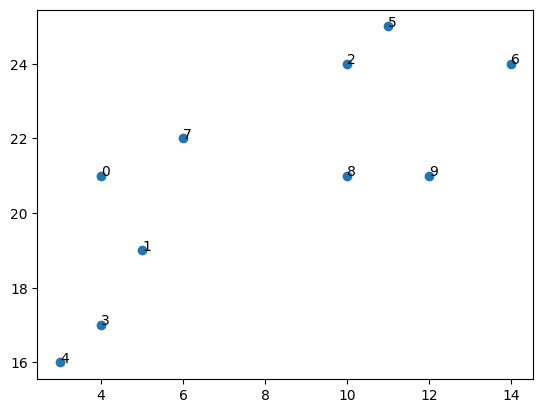

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

fig, ax = plt.subplots()
ax.scatter(x, y)

for i in range(len(x)):
    ax.annotate(i, (x[i], y[i]))

p = []

for i,n in enumerate(x):
    temp = [n,y[i]]
    p.append(temp)

print(p)

In [74]:
import math

def euclidean(p, q):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p, q)))


In [75]:
def cluster_distance(cluster1, cluster2, data):
    min_dist = float("inf")
    for i in cluster1:
        for j in cluster2:
            d = euclidean(data[i], data[j])
            min_dist = min(min_dist, d)
    return min_dist


In [76]:
def hierarchical_clustering(data):
    # Each data point starts as its own cluster
    clusters = [{i} for i in range(len(data))]
    history = []  # store merges for dendrogram

    while len(clusters) > 1:
        min_dist = float("inf")
        pair = None

        # Find closest clusters
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                d = cluster_distance(clusters[i], clusters[j], data)
                if d < min_dist:
                    min_dist = d
                    pair = (i, j)

        i, j = pair
        new_cluster = clusters[i] | clusters[j]

        history.append((clusters[i], clusters[j], min_dist))

        # Remove old clusters and add new one
        clusters.pop(j)
        clusters.pop(i)
        clusters.append(new_cluster)

    return history


In [77]:
history = hierarchical_clustering(p)

for c1, c2, d in history:
    print(c1, c2, "merged at distance", d)

{2} {5} merged at distance 1.4142135623730951
{3} {4} merged at distance 1.4142135623730951
{8} {9} merged at distance 2.0
{0} {1} merged at distance 2.23606797749979
{7} {0, 1} merged at distance 2.23606797749979
{3, 4} {0, 1, 7} merged at distance 2.23606797749979
{2, 5} {8, 9} merged at distance 3.0
{6} {8, 9, 2, 5} merged at distance 3.1622776601683795
{0, 1, 3, 4, 7} {2, 5, 6, 8, 9} merged at distance 4.123105625617661


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_ellipse_onion(history, data):
    data = np.array(data)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect("equal")

    # Plot data points (on top)
    ax.scatter(data[:, 0], data[:, 1], c="black", zorder=10)

    # Annotate each point
    for idx, (x, y) in enumerate(data):
        ax.annotate(
            str(idx),
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
            color="black",
            zorder=11
        )

    padding_step = 0.6

    # Colormap for hierarchy levels
    cmap = plt.cm.viridis
    max_level = len(history)

    for level, (c1, c2, dist) in enumerate(history, start=1):
        merged = frozenset(c1) | frozenset(c2)
        pts = data[list(merged)]

        center = pts.mean(axis=0)

        dx = np.max(np.abs(pts[:, 0] - center[0]))
        dy = np.max(np.abs(pts[:, 1] - center[1]))

        width = 2 * (dx + padding_step * level)
        height = 2 * (dy + padding_step * level)

        # Color based on merge depth (onion layer)
        color = cmap(level / max_level)

        ellipse = Ellipse(
            xy=center,
            width=width,
            height=height,
            facecolor=color,      # ✅ fill color
            edgecolor="black",    # outline
            alpha=0.4,           # transparency
            linewidth=2,
            zorder=level          # deeper layers go underneath
        )

        ax.add_patch(ellipse)

    ax.set_title("Hierarchical Clustering Onion Layers (Filled Ellipses)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True)
    plt.show()


In [79]:
import numpy as np

def history_to_linkage(history, n_points):
    """
    Convert from-scratch hierarchical history to SciPy linkage matrix
    """
    cluster_id = {frozenset([i]): i for i in range(n_points)}
    next_id = n_points
    Z = []

    for c1, c2, dist in history:
        c1, c2 = frozenset(c1), frozenset(c2)

        i = cluster_id[c1]
        j = cluster_id[c2]

        merged = c1 | c2
        count = len(merged)

        Z.append([i, j, dist, count])

        cluster_id[merged] = next_id
        next_id += 1

    return np.array(Z)


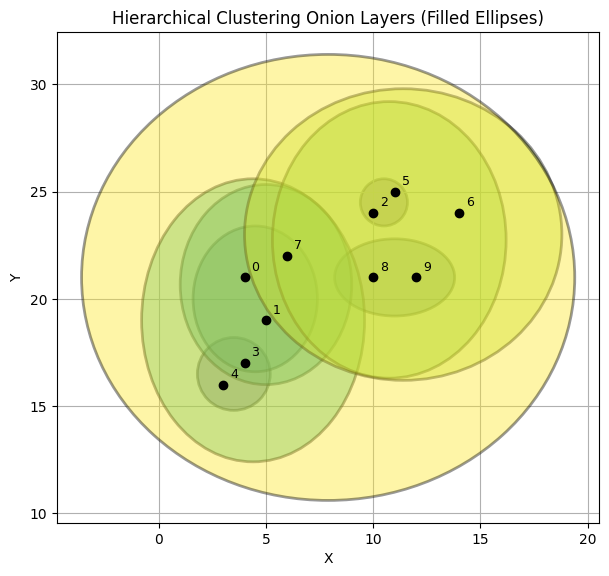

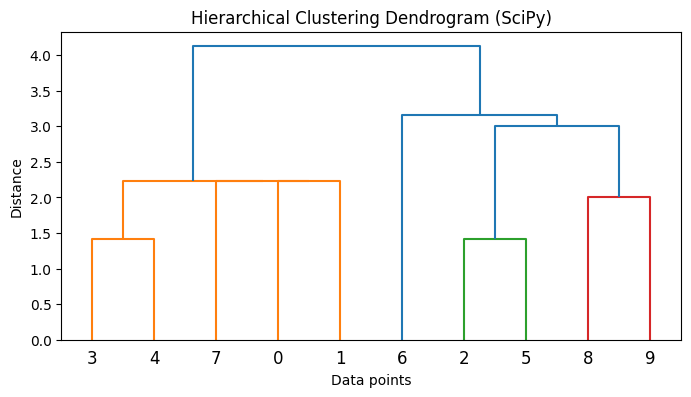

In [80]:
plot_ellipse_onion(history,p)

from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

Z = history_to_linkage(history, n_points=len(p))

plt.figure(figsize=(8, 4))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (SciPy)")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()
